# Allocation Rotation

The companion notebook (`Signals.ipynb`) built factor signals for `SPY`, `EZU`,
and `EWJ`, fit one Ridge model per ETF, and then rotated between them by
holding **exactly one** at a time. That all-or-nothing constraint turned out to
be the binding problem: the model's hit rate against the oracle was barely
above chance (~39% vs. 33%), and the resulting strategy did not beat simply
buying and holding `SPY`.

This notebook keeps the same signals and the same per-ETF models, and changes
only the last step: instead of picking one winner, it maps the three
predictions onto a **portfolio weight vector** — e.g. 50/50 `SPY`/`EZU` in one
period, 33/33/34 across all three in the next, 100% `SPY` in another.

Why this might do better than single-asset rotation:

- **Single-asset rotation throws away information.** Predicting *which* of
  three correlated equity ETFs wins is a much harder question than predicting
  the *degree* to which one looks better than another. Weights can express "SPY
  looks slightly better" without betting the whole portfolio on it.
- **It respects prediction confidence.** When the three predicted returns are
  nearly identical, the model is effectively saying "I don't know" — an all-in
  bet is the wrong response to that, and a near-equal-weight allocation is the
  right one.
- **It changes the turnover profile** — though not necessarily downward, which
  is worth stating carefully. All-in switching trades 200% of the portfolio
  when it changes its mind but *nothing at all* when it doesn't; continuous
  weights trade a little in every period. Which ends up cheaper is an empirical
  question that depends on how often the argmax flips, so the backtest below
  models transaction costs explicitly (never done in the previous notebook, and
  flagged there as an open item) and reports turnover per strategy rather than
  assuming the answer.

What's here:

1. Rebuild the features and the walk-forward out-of-sample predictions from
   `Signals.ipynb` (self-contained — reads the same two raw CSVs).
2. Define three **allocation schemes** that map predictions to weights, each
   with a knob controlling how concentrated the portfolio gets.
3. Backtest with **explicit transaction costs** and turnover accounting.
4. **Tune the allocation hyperparameters on the first part of the rebalance
   history only**, then evaluate the chosen configuration on a held-out tail
   the tuning never saw.
5. Visualize the results, including the tuning surface itself and a check on
   whether tuning-period performance predicts holdout performance at all.

> **Inherited caveat.** The features and the 20-day horizon were selected in
> `Signals.ipynb` using full-sample diagnostics (leakage point #6 in that
> notebook's audit). Nothing here fixes that. The tune/holdout split below is
> honest about the *allocation* hyperparameters only; the underlying feature
> set still had implicit access to the whole sample.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

## 1. Data, features, and models

Reproduced from `Signals.ipynb` so this notebook stands alone. Nothing in this
section is new — skip to section 2 for the actual subject of this notebook.

In [2]:
idx = pd.read_csv("data/Index_ETF_Data_Clean.csv", parse_dates=["Dates"])
rr = pd.read_csv("data/RiskReversalData_Clean.csv", parse_dates=["Dates"])

df = idx.merge(rr, on="Dates", how="inner").sort_values("Dates").set_index("Dates")

rr_cols = {
    "EURUSD25R1M": "EURUSD25R1M BGN Curncy (R1)",
    "USDJPY25R1M": "USDJPY25R1M BGN Curncy (R2)",
    "EURJPY25R1M": "EURJPY25R1M BGN Curncy (L1)",
}

etf_cols = {
    "SPY": {"price": "SPY US Equity PX_LAST", "volume": "SPY US Equity PX_VOLUME",
            "vol_index": "VIX Index PX_LAST"},
    "EZU": {"price": "EZU US Equity PX_LAST", "volume": "EZU US Equity PX_VOLUME",
            "vol_index": "V2X Index PX_LAST"},
    "EWJ": {"price": "EWJ US Equity PX_LAST", "volume": "EWJ US Equity PX_VOLUME",
            "vol_index": "NKYVF Index PX_LAST"},
}

ETFS = list(etf_cols)
print(f"{df.shape[0]} rows, {df.index.min().date()} to {df.index.max().date()}")

3762 rows, 2012-02-27 to 2026-07-28


### Data quality check on the volatility indices

The companion notebook's single strongest factor was each ETF's own volatility
index level, so these three series carry a lot of weight. They are also the
easiest thing in the dataset to get quietly wrong: a mis-mapped Bloomberg
ticker returns numbers, not an error, and a decaying futures series looks
superficially like an index.

Three cheap checks catch the realistic failure modes:

- **Correlation with the ETF's own realized volatility.** A working volatility
  index tracks the realized volatility of its market. This should be strongly
  positive; near zero means the series is measuring something else.
- **Largest single-day log jump.** Volatility indices move violently but not
  discontinuously. A jump of more than ~1 log unit is a rebasing,
  redenomination, or ticker splice, not a market event.
- **Correlation with a plain time trend.** Volatility is mean-reverting and
  roughly stationary over a decade. A series that trends monotonically is a
  price-like or decaying instrument, and feeding its *level* into a regression
  against forward returns is a spurious-regression trap: the model fits the
  trend, not the volatility.

In [3]:
def volidx_audit():
    rows = []
    for etf, cols in etf_cols.items():
        vi = df[cols["vol_index"]]
        realized = df[cols["price"]].pct_change().rolling(20).std() * np.sqrt(252) * 100

        paired = pd.concat([vi, realized], axis=1).dropna()
        corr_realized = paired.iloc[:, 0].corr(paired.iloc[:, 1], method="spearman")

        positive = vi.where(vi > 0)
        max_jump = np.log(positive).diff().abs().max()

        clean = vi.dropna()
        corr_trend = spearmanr(clean.to_numpy(), np.arange(len(clean))).correlation

        rows.append({
            "etf": etf, "series": cols["vol_index"],
            "corr_realized_vol": corr_realized,
            "max_1d_log_jump": max_jump,
            "corr_time_trend": corr_trend,
            "passes": bool(corr_realized > 0.30 and max_jump < 1.0 and abs(corr_trend) < 0.50),
        })
    return pd.DataFrame(rows).set_index("etf")


VOLIDX_AUDIT = volidx_audit()
VOLIDX_OK = VOLIDX_AUDIT["passes"].to_dict()

print(VOLIDX_AUDIT.round(3).to_string())
failed = [e for e, ok in VOLIDX_OK.items() if not ok]
if failed:
    print(f"\nWARNING: volatility index failed the audit for {', '.join(failed)}. "
          f"See DROP_FAILED_VOLIDX in the configuration cell.")

                  series  corr_realized_vol  max_1d_log_jump  corr_time_trend  passes
etf                                                                                  
SPY    VIX Index PX_LAST              0.739            0.768            0.327    True
EZU    V2X Index PX_LAST              0.687            0.486           -0.108    True
EWJ  NKYVF Index PX_LAST              0.091            4.605           -0.593   False



In [4]:
features = pd.DataFrame(index=df.index)

# --- Risk-reversal levels ---
for name, col in rr_cols.items():
    features[f"{name}_level"] = df[col]

# --- Local-currency-demand risk reversals (sign-corrected) ---
RR_BASE_CURRENCY = {"EURUSD25R1M": "EUR", "USDJPY25R1M": "USD", "EURJPY25R1M": "EUR"}
ETF_LOCAL_CURRENCY = {"SPY": "USD", "EZU": "EUR", "EWJ": "JPY"}
LOCAL_CURRENCY_RR_PAIRS = {
    "SPY": ["EURUSD25R1M", "USDJPY25R1M"],
    "EZU": ["EURUSD25R1M", "EURJPY25R1M"],
    "EWJ": ["USDJPY25R1M", "EURJPY25R1M"],
}

for etf, local_ccy in ETF_LOCAL_CURRENCY.items():
    for rr_name in LOCAL_CURRENCY_RR_PAIRS[etf]:
        sign = 1 if RR_BASE_CURRENCY[rr_name] == local_ccy else -1
        features[f"{etf}_{rr_name}_ccy_demand"] = sign * features[f"{rr_name}_level"]

# --- Own-asset price / volume / volatility-index factors ---
for etf, cols in etf_cols.items():
    price, volume, vol_idx = df[cols["price"]], df[cols["volume"]], df[cols["vol_index"]]

    for w in (5, 20, 60):
        features[f"{etf}_mom_{w}d"] = price.pct_change(w)

    features[f"{etf}_price_vs_sma50"] = price / price.rolling(50, min_periods=25).mean() - 1
    features[f"{etf}_rel_volume_20d"] = volume / volume.rolling(20, min_periods=10).mean() - 1
    features[f"{etf}_volume_chg_5d"] = volume.pct_change(5)

    features[f"{etf}_volidx_level"] = vol_idx
    features[f"{etf}_volidx_chg_5d"] = vol_idx.diff(5)
    features[f"{etf}_volidx_chg_20d"] = vol_idx.diff(20)
    vi_mean60 = vol_idx.rolling(60, min_periods=30).mean()
    vi_std60 = vol_idx.rolling(60, min_periods=30).std()
    features[f"{etf}_volidx_zscore_60d"] = (vol_idx - vi_mean60) / vi_std60

print(f"{features.shape[1]} features built")

39 features built


## 2. Configuration

Everything downstream is driven by this cell. The model half (`PREDICT_HORIZON`
through `ALPHA_GRID`) matches `Signals.ipynb`; the rest is new.

`COST_BPS` is the one that changes the character of the exercise most. The
previous notebook reported all results gross of costs and listed pricing
turnover as an open item. Single-asset rotation trades 200% of the portfolio on
every switch, so costs bite it far harder than they bite a weighting scheme
that moves gradually — which means a cost-free comparison is quietly biased in
favour of the strategy this notebook is trying to improve on.

In [5]:
# ---- Model (unchanged from Signals.ipynb) ----
PREDICT_HORIZON = 20           # forward-return horizon the Ridge models target
N_WALKFORWARD_FOLDS = 5        # expanding-window folds for out-of-sample predictions
ALPHA_GRID = np.logspace(-2, 6, 40)

INCLUDE_MOMENTUM = True
INCLUDE_TREND = True
INCLUDE_VOLUME = True
INCLUDE_VOLIDX = True
INCLUDE_RISK_REVERSAL = True

# Exclude volatility-index features for any ETF whose index failed the audit
# above. Set to False to reproduce the companion notebook's feature set exactly.
DROP_FAILED_VOLIDX = True

# ---- Portfolio ----
REBALANCE_EVERY = 20           # trading days between rebalances
COST_BPS = 5.0                 # per-side transaction cost, in bps of notional traded
PERIODS_PER_YEAR = 252 / REBALANCE_EVERY

# ---- Covariance estimate (used by the mean-variance scheme) ----
COV_WINDOW = 252               # trailing daily observations
COV_SHRINKAGE = 0.20           # 0 = raw sample cov, 1 = diagonal only

# ---- Allocation hyperparameter tuning ----
TUNE_FRACTION = 0.60           # first 60% of rebalance dates tune; last 40% is holdout
SIMPLEX_STEP = 0.02            # weight-grid resolution for the mean-variance optimizer

RISK_REVERSAL_PAIRING = {
    etf: [f"{etf}_{rr}_ccy_demand" for rr in pairs]
    for etf, pairs in LOCAL_CURRENCY_RR_PAIRS.items()
}


def build_feature_set(etf):
    cols = []
    if INCLUDE_MOMENTUM:
        cols += [f"{etf}_mom_20d", f"{etf}_mom_60d"]
    if INCLUDE_TREND:
        cols.append(f"{etf}_price_vs_sma50")
    if INCLUDE_VOLUME:
        cols.append(f"{etf}_rel_volume_20d")
    if INCLUDE_VOLIDX and (VOLIDX_OK[etf] or not DROP_FAILED_VOLIDX):
        cols += [f"{etf}_volidx_level", f"{etf}_volidx_chg_20d", f"{etf}_volidx_zscore_60d"]
    if INCLUDE_RISK_REVERSAL:
        cols += RISK_REVERSAL_PAIRING.get(etf, [])
    return cols


def forward_return(etf, days):
    '''Actual return from today's close to `days` trading days ahead.'''
    price = df[etf_cols[etf]["price"]]
    return price.shift(-days) / price - 1


model_feature_sets = {etf: build_feature_set(etf) for etf in ETFS}
{etf: len(cols) for etf, cols in model_feature_sets.items()}

{'SPY': 9, 'EZU': 9, 'EWJ': 6}

### Walk-forward out-of-sample predictions

Identical to `Signals.ipynb`: expanding-window folds, scaler and `RidgeCV`
refit inside each fold on training rows only, `PREDICT_HORIZON` rows embargoed
between train and test so no training row's forward-return window reaches into
the evaluation slice. Every prediction below was made with information
available at the time.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

pred_series = {}

for etf, feature_cols in model_feature_sets.items():

    target_col = f"{etf}_fwd_ret_{PREDICT_HORIZON}d"

    target = forward_return(
        etf,
        PREDICT_HORIZON
    ).rename(target_col)

    data = pd.concat(
        [features[feature_cols], target],
        axis=1
    ).dropna().sort_index()

    n = len(data)

    fold_bounds = np.linspace(
        0,
        n,
        N_WALKFORWARD_FOLDS + 2
    ).astype(int)

    fold_preds = []

    for i in range(1, N_WALKFORWARD_FOLDS + 1):

        train_end = fold_bounds[i] - PREDICT_HORIZON
        test_start = fold_bounds[i]
        test_end = fold_bounds[i + 1]

        train = data.iloc[:train_end]
        test = data.iloc[test_start:test_end]

        # Skip folds that are empty or too small
        if len(train) <= 4 or len(test) == 0:
            continue

        scaler = StandardScaler()

        X_train = scaler.fit_transform(train[feature_cols])
        X_test = scaler.transform(test[feature_cols])

        y_train = train[target_col].to_numpy()

        # Avoids the scipy/scikit-learn sym_pos compatibility error
        ridge = Ridge(solver="lsqr")

        model = GridSearchCV(
            estimator=ridge,
            param_grid={"alpha": ALPHA_GRID},
            cv=TimeSeriesSplit(n_splits=4),
            scoring="neg_mean_squared_error",
            refit=True
        )

        model.fit(X_train, y_train)

        fold_prediction = pd.Series(
            model.predict(X_test),
            index=test.index,
            name=etf
        )

        fold_preds.append(fold_prediction)

    if fold_preds:
        pred_series[etf] = pd.concat(fold_preds).sort_index()
    else:
        pred_series[etf] = pd.Series(dtype=float, name=etf)


# Combine predictions and retain the desired ETF order
pred_df = pd.DataFrame(pred_series)

missing_etfs = [etf for etf in ETFS if etf not in pred_df.columns]

if missing_etfs:
    raise ValueError(
        f"No predictions were generated for: {missing_etfs}"
    )

pred_df = pred_df[ETFS].dropna()


# Actual holding-period returns at the portfolio's real rebalance cadence
actual_returns = pd.DataFrame({
    etf: forward_return(etf, REBALANCE_EVERY)
    for etf in ETFS
}).sort_index()


# Select every REBALANCE_EVERY-th available prediction date
rebalance_dates = pred_df.index[::REBALANCE_EVERY]

# Ensure selected dates also exist in actual_returns
rebalance_dates = rebalance_dates.intersection(actual_returns.index)

# Retain dates where all ETF holding-period returns are available
valid_dates = (
    actual_returns
    .loc[rebalance_dates, ETFS]
    .notna()
    .all(axis=1)
)

rebalance_dates = rebalance_dates[
    valid_dates.to_numpy()
]

# Align both predictions and actual returns to the same dates
pred_df = pred_df.loc[rebalance_dates, ETFS]
actual_df = actual_returns.loc[rebalance_dates, ETFS]


if len(rebalance_dates) > 0:
    print(
        f"{len(rebalance_dates)} rebalance periods of "
        f"{REBALANCE_EVERY} trading days, "
        f"{rebalance_dates.min().date()} to "
        f"{rebalance_dates.max().date()}"
    )

    display(pred_df.tail(3))

else:
    print("No valid rebalance periods were produced.")

154 rebalance periods of 20 trading days, 2014-09-25 to 2026-06-18


,SPY,EZU,EWJ
Dates,,,
2026-04-23,0.008790,0.006806,0.004037
2026-05-21,0.006918,0.008157,0.005077
2026-06-18,0.004042,0.008707,0.006219


## 3. From predictions to weights

Three predicted returns per date have to become three weights that are
non-negative and sum to one. Two decisions are separated deliberately, because
they answer different questions.

**Decision A — how much of the prediction do you believe?** The previous
notebook found that per-fold refitting leaves predictions on an inconsistent
scale across regimes (its pooled out-of-sample IC was much weaker than the
average per-fold IC, precisely because of this). A weighting scheme that reads
the *magnitude* of predicted returns literally will therefore be more
aggressive in some regimes than others for reasons that have nothing to do with
signal strength. Three `transform` options span the range of how much to trust:

| transform | keeps | throws away |
|---|---|---|
| `demean` | the full spread between predictions | the common level (irrelevant when weights must sum to 1) |
| `zscore` | the shape of the spread | its size — each date is rescaled to unit cross-sectional dispersion |
| `rank` | the ordering only | all magnitude information |

`rank` is the most defensive and `demean` the most trusting. Which one wins is
an empirical question, so it goes in the tuning grid.

**Decision B — how concentrated should the portfolio be?** Three schemes:

- **`top_k`** — equal-weight the best `k` of three. `k=1` reproduces the
  previous notebook's single-asset rotation exactly; `k=3` is fixed
  equal-weight and ignores the signal entirely; `k=2` is the 50/50 case. This
  scheme is the bridge between the old approach and the new one, and having
  both endpoints inside the same grid means the tuner can tell us directly
  whether partial allocation beats either extreme.
- **`softmax`** — `w ∝ exp(signal / τ)`. Temperature `τ` slides continuously
  from winner-take-all (`τ → 0`) to equal weight (`τ → ∞`). Unlike `top_k` it
  responds to *how much* better the leader looks, which is the property we
  actually want.
- **`mean_variance`** — maximize `w'μ − (γ/2)·w'Σw` subject to long-only and
  fully invested. The only scheme that knows the three ETFs are correlated;
  the other two would happily put 100% into the highest-predicted asset even
  if it were also the most volatile.

A `max_weight` cap applies on top of `softmax` and `mean_variance` as a blunt
concentration limit (the floor is 1/3, since three assets must sum to one).

In [8]:
def transform_signal(pred_row, mode):
    '''Map one date's three predicted returns onto a comparable signal vector.'''
    x = np.asarray(pred_row, dtype=float)
    if mode == "demean":
        return x - x.mean()
    if mode == "zscore":
        sd = x.std()
        return (x - x.mean()) / sd if sd > 1e-12 else np.zeros_like(x)
    if mode == "rank":
        # Centered ranks, scaled to unit dispersion so tau/gamma grids are
        # comparable with the zscore transform.
        r = pd.Series(x).rank().to_numpy()
        r = r - r.mean()
        sd = r.std()
        return r / sd if sd > 1e-12 else np.zeros_like(r)
    raise ValueError(f"unknown transform: {mode}")


def cap_weights(w, max_weight):
    '''Enforce w_i <= max_weight, redistributing the excess pro rata.'''
    n = len(w)
    if max_weight >= 1.0:
        return w
    # A cap below 1/n is infeasible for weights summing to 1.
    max_weight = max(max_weight, 1.0 / n + 1e-12)

    w = np.asarray(w, dtype=float).copy()
    for _ in range(50):
        over = w > max_weight + 1e-12
        if not over.any():
            break
        excess = (w[over] - max_weight).sum()
        w[over] = max_weight
        under = ~over
        pool = w[under].sum()
        if pool > 1e-12:
            w[under] += excess * w[under] / pool
        else:
            w[under] += excess / under.sum()
    return w / w.sum()


def make_simplex_grid(n_assets, step):
    '''All weight vectors on the unit simplex at the given resolution.'''
    m = int(round(1 / step))

    def rec(remaining, slots):
        if slots == 1:
            yield (remaining,)
            return
        for i in range(remaining + 1):
            for rest in rec(remaining - i, slots - 1):
                yield (i,) + rest

    return np.array(list(rec(m, n_assets)), dtype=float) / m


SIMPLEX_GRID = make_simplex_grid(len(ETFS), SIMPLEX_STEP)
print(f"simplex grid: {len(SIMPLEX_GRID)} candidate weight vectors "
      f"at {SIMPLEX_STEP:.0%} resolution")

simplex grid: 1326 candidate weight vectors at 2% resolution


The mean-variance scheme needs a covariance matrix. It is estimated from a
trailing window of **daily** ETF returns, scaled up to the prediction horizon,
and shrunk toward its diagonal — a three-asset sample covariance from 252
observations is noisy enough that a small shrinkage meaningfully stabilizes the
resulting weights.

The window ends *on* the rebalance date, so it uses the return realized that
day and nothing after it: no look-ahead.

In [9]:
daily_returns = pd.DataFrame(
    {etf: df[etf_cols[etf]["price"]].pct_change() for etf in ETFS}
)[ETFS]


def horizon_covariance(date, window=COV_WINDOW, horizon=PREDICT_HORIZON):
    '''Trailing daily covariance as of `date`, scaled to the prediction horizon.'''
    hist = daily_returns.loc[:date].iloc[-window:].dropna()
    return hist.cov().to_numpy() * horizon


def shrink_covariance(cov, shrinkage=COV_SHRINKAGE):
    return (1 - shrinkage) * cov + shrinkage * np.diag(np.diag(cov))


# Precomputed once: it depends only on the date, not on any tuned hyperparameter.
COV_BY_DATE = {d: horizon_covariance(d) for d in rebalance_dates}

sample_cov = shrink_covariance(COV_BY_DATE[rebalance_dates[-1]])
print(f"Annualized vols implied by the final covariance estimate "
      f"({rebalance_dates[-1].date()}):")
print(pd.Series(np.sqrt(np.diag(sample_cov) * PERIODS_PER_YEAR), index=ETFS).round(3).to_string())

Annualized vols implied by the final covariance estimate (2026-06-18):
SPY    0.123
EZU    0.173
EWJ    0.200


In [10]:
def weights_top_k(signal, k, **kwargs):
    w = np.zeros(len(signal))
    w[np.argsort(-signal)[:k]] = 1.0 / k
    return w


def weights_softmax(signal, temperature, max_weight=1.0, **kwargs):
    z = signal / temperature
    z = z - z.max()                 # shift for numerical stability; softmax is shift-invariant
    w = np.exp(z)
    return cap_weights(w / w.sum(), max_weight)


def weights_mean_variance(signal, gamma, cov, max_weight=1.0, shrinkage=COV_SHRINKAGE, **kwargs):
    '''Grid-search the simplex for max w'mu - (gamma/2) w'Sigma w.

    A dense grid rather than a solver: with three assets it is fast, exactly
    respects the long-only / fully-invested / capped constraints, and cannot
    fail to converge.
    '''
    sigma = shrink_covariance(cov, shrinkage)
    feasible = SIMPLEX_GRID[(SIMPLEX_GRID <= max_weight + 1e-9).all(axis=1)]
    if len(feasible) == 0:
        feasible = SIMPLEX_GRID
    utility = feasible @ signal - 0.5 * gamma * np.einsum("ij,jk,ik->i", feasible, sigma, feasible)
    return feasible[int(np.argmax(utility))]


SCHEMES = {
    "top_k": weights_top_k,
    "softmax": weights_softmax,
    "mean_variance": weights_mean_variance,
}


def build_weights(config, dates):
    '''Weight matrix (dates x ETFs) produced by one allocation configuration.'''
    scheme = SCHEMES[config["scheme"]]
    params = {k: v for k, v in config.items() if k not in ("scheme", "transform")}

    rows = np.empty((len(dates), len(ETFS)))
    for i, date in enumerate(dates):
        signal = transform_signal(pred_df.loc[date, ETFS], config["transform"])
        rows[i] = scheme(signal, cov=COV_BY_DATE[date], **params)

    return pd.DataFrame(rows, index=dates, columns=ETFS)

### Backtest engine

Two details worth stating explicitly, because they are the difference between
a plausible-looking backtest and an honest one.

**Weights drift within a period.** Holding 50/50 for 20 days does not leave you
at 50/50 — the better performer ends the period at more than half the
portfolio. Turnover is therefore measured against the *drifted* end-of-period
weights, not against the previous target. Ignoring drift would overstate
turnover, penalizing every strategy, but it would penalize the gradual ones
most, which is exactly the comparison this notebook cares about.

**Costs are charged on notional traded.** `sum(|w_new − w_drifted|)` counts both
legs of a switch (the sale and the purchase), so multiplying it by a per-side
cost is the right accounting. A full single-asset switch costs `2 × COST_BPS`;
holding weights steady costs nothing.

In [11]:
def backtest(weights, actual, cost_bps=COST_BPS):
    '''Period returns, gross and net of costs, plus turnover, for a weight path.'''
    dates = weights.index
    W = weights.to_numpy()
    R = actual.loc[dates, ETFS].to_numpy()

    gross, traded_frac = np.empty(len(dates)), np.empty(len(dates))
    held = np.zeros(len(ETFS))          # start in cash: the first rebalance is a full purchase

    for i in range(len(dates)):
        w = W[i]
        traded_frac[i] = np.abs(w - held).sum()
        gross[i] = w @ R[i]
        # Drift: what the weights become by the end of the holding period.
        held = w * (1 + R[i]) / (1 + gross[i])

    cost = traded_frac * cost_bps / 1e4
    return pd.DataFrame(
        {"gross": gross, "cost": cost, "net": gross - cost, "traded": traded_frac},
        index=dates,
    )


def performance_stats(net_returns, periods_per_year=PERIODS_PER_YEAR):
    growth = (1 + net_returns).cumprod()
    ann_return = growth.iloc[-1] ** (periods_per_year / len(net_returns)) - 1
    ann_vol = net_returns.std() * np.sqrt(periods_per_year)
    downside = net_returns[net_returns < 0]
    downside_dev = downside.std() * np.sqrt(periods_per_year) if len(downside) > 1 else np.nan
    return pd.Series({
        "total_return": growth.iloc[-1] - 1,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": ann_return / ann_vol if ann_vol > 0 else np.nan,
        "sortino": ann_return / downside_dev if downside_dev and downside_dev > 0 else np.nan,
        "max_drawdown": (growth / growth.cummax() - 1).min(),
        "hit_rate": (net_returns > 0).mean(),
    })


def evaluate(config, dates, cost_bps=COST_BPS):
    weights = build_weights(config, dates)
    bt = backtest(weights, actual_df, cost_bps)
    stats = performance_stats(bt["net"])
    stats["ann_turnover"] = bt["traded"].mean() * PERIODS_PER_YEAR
    stats["cost_drag"] = bt["cost"].mean() * PERIODS_PER_YEAR
    return weights, bt, stats

## 4. Hyperparameter tuning

The allocation scheme has knobs, and knobs invite overfitting. The protocol
here is deliberately conservative:

1. Split the rebalance dates chronologically — the first `TUNE_FRACTION` tunes,
   the rest is a **holdout that the search never sees**.
2. Score every configuration on the tuning period by **net-of-cost Sharpe**.
3. Pick the winner, then report it on the holdout.

Step 3 is reported *once*. The moment you look at a holdout result and go back
to change the grid, it stops being a holdout — so the tuning grid below is
fixed in advance and the holdout numbers appear only after it.

One extra diagnostic, which matters more than the winning configuration
itself: every config is also scored on the holdout, and the rank correlation
between tuning score and holdout score is reported. If that correlation is near
zero, the tuning step is not finding anything durable, and the "best" config is
just the luckiest one — a possibility worth measuring rather than assuming
away, given that the previous notebook found the underlying signal to be
regime-dependent.

In [12]:
n_tune = int(len(rebalance_dates) * TUNE_FRACTION)
tune_dates = rebalance_dates[:n_tune]
holdout_dates = rebalance_dates[n_tune:]

print(f"tuning : {len(tune_dates)} periods, {tune_dates.min().date()} to {tune_dates.max().date()}")
print(f"holdout: {len(holdout_dates)} periods, {holdout_dates.min().date()} to {holdout_dates.max().date()}")

tuning : 92 periods, 2014-09-25 to 2021-09-16
holdout: 62 periods, 2021-10-14 to 2026-06-18


In [13]:
TRANSFORMS = ["demean", "zscore", "rank"]
MAX_WEIGHTS = [0.50, 0.70, 1.00]
TEMPERATURES = np.logspace(-3, 0, 7)      # spans winner-take-all to near-equal-weight
GAMMAS = np.logspace(-1, 3, 9)            # risk aversion

configs = []

# top_k is invariant to any monotone transform of the signal, so it is only
# enumerated once rather than three times.
for k in (1, 2, 3):
    configs.append({"scheme": "top_k", "transform": "demean", "k": k})

for transform in TRANSFORMS:
    for tau in TEMPERATURES:
        for mw in MAX_WEIGHTS:
            configs.append({"scheme": "softmax", "transform": transform,
                            "temperature": float(tau), "max_weight": mw})
    for gamma in GAMMAS:
        for mw in MAX_WEIGHTS:
            configs.append({"scheme": "mean_variance", "transform": transform,
                            "gamma": float(gamma), "max_weight": mw})


def config_label(config):
    if config["scheme"] == "top_k":
        return f"top_k(k={config['k']})"
    if config["scheme"] == "softmax":
        return (f"softmax(tau={config['temperature']:.3g}, "
                f"max={config['max_weight']:.2f}, {config['transform']})")
    return (f"mean_var(gamma={config['gamma']:.3g}, "
            f"max={config['max_weight']:.2f}, {config['transform']})")


print(f"{len(configs)} configurations to evaluate")

147 configurations to evaluate


In [14]:
records = []

for config in configs:
    _, _, tune_stats = evaluate(config, tune_dates)
    _, _, hold_stats = evaluate(config, holdout_dates)   # recorded, NOT used for selection
    records.append({
        "config": config,
        "label": config_label(config),
        "scheme": config["scheme"],
        "transform": config["transform"],
        "tune_sharpe": tune_stats["sharpe"],
        "tune_ann_return": tune_stats["ann_return"],
        "tune_turnover": tune_stats["ann_turnover"],
        "holdout_sharpe": hold_stats["sharpe"],
        "holdout_ann_return": hold_stats["ann_return"],
    })

tuning_results = pd.DataFrame(records).sort_values("tune_sharpe", ascending=False)

print("Top 10 configurations by TUNING-period net Sharpe:")
tuning_results.head(10)[
    ["label", "tune_sharpe", "tune_ann_return", "tune_turnover", "holdout_sharpe"]
].reset_index(drop=True)

Top 10 configurations by TUNING-period net Sharpe:


,label,tune_sharpe,tune_ann_return,tune_turnover,holdout_sharpe
0,"mean_var(gamma=100, max=1.00, demean)",0.706551,0.093153,1.920400,0.795557
1,"mean_var(gamma=100, max=0.70, demean)",0.698723,0.092015,1.559597,0.795226
2,"mean_var(gamma=1e+03, max=1.00, rank)",0.695281,0.103100,7.571788,0.782329
3,"mean_var(gamma=316, max=0.70, demean)",0.692114,0.091100,1.166769,0.772395
4,"mean_var(gamma=1e+03, max=0.70, demean)",0.688484,0.090430,1.035099,0.762805
5,"mean_var(gamma=31.6, max=0.50, demean)",0.686796,0.093399,1.997448,0.791429
6,"mean_var(gamma=1e+03, max=1.00, zscore)",0.685892,0.100696,7.440784,0.759498
7,"mean_var(gamma=316, max=1.00, demean)",0.685015,0.090032,1.347429,0.777137
8,"softmax(tau=1, max=1.00, zscore)",0.681128,0.099803,5.328046,0.779541
9,"mean_var(gamma=1e+03, max=1.00, demean)",0.680892,0.089359,1.246056,0.768627


### The tuning surface

Each heatmap shows net Sharpe over the tuning period across the concentration
knob and the weight cap, one panel per signal transform. Flat panels mean the
knob does not matter; a sharp single-cell peak surrounded by mediocre values is
a warning that the winner is noise rather than a real optimum.

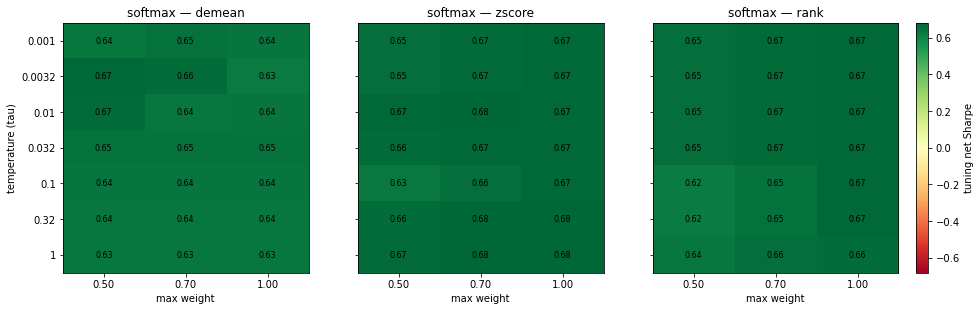

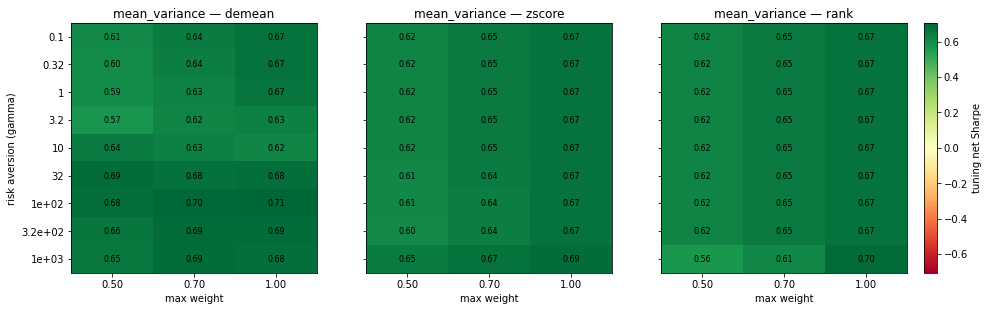

In [15]:
def tuning_heatmap(scheme, param, param_label, fmt="{:.2g}"):
    subset = tuning_results[tuning_results["scheme"] == scheme].copy()
    subset[param] = subset["config"].apply(lambda c: c[param])
    subset["max_weight"] = subset["config"].apply(lambda c: c["max_weight"])

    vmax = np.nanmax(np.abs(subset["tune_sharpe"]))
    fig, axes = plt.subplots(1, len(TRANSFORMS), figsize=(5.2 * len(TRANSFORMS), 4.6),
                             sharey=True)

    for ax, transform in zip(np.atleast_1d(axes), TRANSFORMS):
        pivot = (subset[subset["transform"] == transform]
                 .pivot(index=param, columns="max_weight", values="tune_sharpe")
                 .sort_index())
        values = pivot.to_numpy()
        im = ax.imshow(values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{c:.2f}" for c in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([fmt.format(v) for v in pivot.index])
        ax.set_xlabel("max weight")
        ax.set_title(f"{scheme} — {transform}")

        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center", fontsize=8)

    np.atleast_1d(axes)[0].set_ylabel(param_label)
    fig.colorbar(im, ax=axes, label="tuning net Sharpe", fraction=0.02, pad=0.02)
    plt.show()


tuning_heatmap("softmax", "temperature", "temperature (tau)")
tuning_heatmap("mean_variance", "gamma", "risk aversion (gamma)")

In [16]:
top_k_rows = tuning_results[tuning_results["scheme"] == "top_k"].copy()
top_k_rows["k"] = top_k_rows["config"].apply(lambda c: c["k"])
top_k_rows = top_k_rows.sort_values("k")

print("top_k reference points (k=1 is the previous notebook's strategy, "
      "k=3 is fixed equal weight):")
top_k_rows[["label", "tune_sharpe", "tune_turnover", "holdout_sharpe"]].reset_index(drop=True)

top_k reference points (k=1 is the previous notebook's strategy, k=3 is fixed equal weight):


,label,tune_sharpe,tune_turnover,holdout_sharpe
0,top_k(k=1),0.671453,7.258696,0.791942
1,top_k(k=2),0.618847,4.758858,0.818854
2,top_k(k=3),0.633603,0.290718,0.719142


### Does tuning-period performance predict holdout performance?

The scatter below is the honest check on the whole tuning exercise. Each point
is one configuration. If the cloud slopes upward, choosing on tuning Sharpe is
a rational way to choose. If it is a shapeless blob, the search is fitting
noise and the selected configuration carries no expectation of holding up.

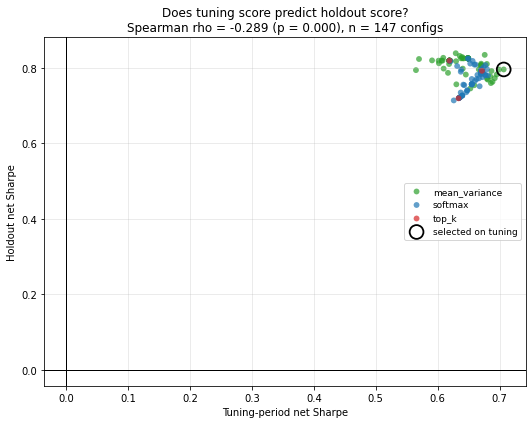

selected on tuning : mean_var(gamma=100, max=1.00, demean)
    tuning Sharpe 0.707 -> holdout Sharpe 0.796
best on holdout (not knowable in advance): mean_var(gamma=1, max=0.70, demean)
    holdout Sharpe 0.838, but ranked 119 of 147 on tuning

configs beating single-asset rotation on the holdout: 71 of 147
configs identical to top_k(k=1) on tuning (corner solutions): 23


In [17]:
valid = tuning_results.dropna(subset=["tune_sharpe", "holdout_sharpe"])
rho, pval = spearmanr(valid["tune_sharpe"], valid["holdout_sharpe"])

scheme_colors = {"top_k": "#d62728", "softmax": "#1f77b4", "mean_variance": "#2ca02c"}

plt.figure(figsize=(7.5, 6))
for scheme, group in valid.groupby("scheme"):
    plt.scatter(group["tune_sharpe"], group["holdout_sharpe"], s=34, alpha=0.7,
                label=scheme, color=scheme_colors[scheme], edgecolors="none")

best_row = tuning_results.iloc[0]
plt.scatter([best_row["tune_sharpe"]], [best_row["holdout_sharpe"]],
            s=190, facecolors="none", edgecolors="black", linewidths=1.8,
            label="selected on tuning", zorder=5)

plt.axhline(0, linewidth=1, color="black")
plt.axvline(0, linewidth=1, color="black")
plt.xlabel("Tuning-period net Sharpe")
plt.ylabel("Holdout net Sharpe")
plt.title(f"Does tuning score predict holdout score?\n"
          f"Spearman rho = {rho:.3f} (p = {pval:.3f}), n = {len(valid)} configs")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

baseline = tuning_results[tuning_results["label"] == "top_k(k=1)"].iloc[0]
best_holdout = valid.sort_values("holdout_sharpe", ascending=False).iloc[0]
tune_rank_of_best = int((valid["tune_sharpe"] > best_holdout["tune_sharpe"]).sum()) + 1

print(f"selected on tuning : {best_row['label']}")
print(f"    tuning Sharpe {best_row['tune_sharpe']:.3f} -> holdout Sharpe "
      f"{best_row['holdout_sharpe']:.3f}")
print(f"best on holdout (not knowable in advance): {best_holdout['label']}")
print(f"    holdout Sharpe {best_holdout['holdout_sharpe']:.3f}, but ranked "
      f"{tune_rank_of_best} of {len(valid)} on tuning")
print(f"\nconfigs beating single-asset rotation on the holdout: "
      f"{(valid['holdout_sharpe'] > baseline['holdout_sharpe']).sum()} of {len(valid)}")
print(f"configs identical to top_k(k=1) on tuning (corner solutions): "
      f"{int(np.isclose(valid['tune_sharpe'], baseline['tune_sharpe'], atol=1e-9).sum())}")

## 5. Holdout evaluation

The configuration selected above, run on the holdout period against a full set
of benchmarks — all net of the same transaction costs:

- **`single_asset_rotation`** — the previous notebook's strategy (`top_k`,
  `k=1`), now paying for its turnover. This is the comparison the notebook
  exists to make.
- **`equal_weight`** — fixed 1/3 each, rebalanced on the same cadence. Uses no
  signal at all.
- **`inverse_vol`** — weights proportional to the reciprocal of each ETF's
  trailing volatility. Also uses no return signal, only risk. Included because
  a signal-driven allocation that cannot beat a pure risk-weighting rule has
  not demonstrated that its *predictions* are doing the work.
- **`SPY_only` / `EZU_only` / `EWJ_only`** — buy and hold. `SPY_only` was the
  bar the previous notebook failed to clear.
- **`oracle_best_single`** — perfect foresight, all-in on the best performer
  each period. Not attainable; included as the ceiling.

In [18]:
best_config = best_row["config"]
print(f"selected: {config_label(best_config)}")


def fixed_weight_frame(weight_vector, dates):
    return pd.DataFrame(np.tile(weight_vector, (len(dates), 1)), index=dates, columns=ETFS)


def inverse_vol_weights(dates):
    rows = []
    for d in dates:
        vol = np.sqrt(np.diag(COV_BY_DATE[d]))
        inv = 1.0 / np.where(vol > 1e-12, vol, np.nan)
        rows.append(inv / np.nansum(inv))
    return pd.DataFrame(rows, index=dates, columns=ETFS)


def oracle_weights(dates):
    best = actual_df.loc[dates, ETFS].to_numpy().argmax(axis=1)
    W = np.zeros((len(dates), len(ETFS)))
    W[np.arange(len(dates)), best] = 1.0
    return pd.DataFrame(W, index=dates, columns=ETFS)


def build_all_weights(dates):
    weights = {
        "tuned_allocation": build_weights(best_config, dates),
        "single_asset_rotation": build_weights(
            {"scheme": "top_k", "transform": "demean", "k": 1}, dates),
        "equal_weight": fixed_weight_frame(np.ones(len(ETFS)) / len(ETFS), dates),
        "inverse_vol": inverse_vol_weights(dates),
    }
    for i, etf in enumerate(ETFS):
        weights[f"{etf}_only"] = fixed_weight_frame(np.eye(len(ETFS))[i], dates)
    weights["oracle_best_single"] = oracle_weights(dates)
    return weights


holdout_weights = build_all_weights(holdout_dates)
holdout_bt = {name: backtest(w, actual_df) for name, w in holdout_weights.items()}

holdout_performance = pd.DataFrame({
    name: pd.concat([
        performance_stats(bt["net"]),
        pd.Series({"ann_turnover": bt["traded"].mean() * PERIODS_PER_YEAR,
                   "cost_drag": bt["cost"].mean() * PERIODS_PER_YEAR}),
    ])
    for name, bt in holdout_bt.items()
}).T

holdout_performance.sort_values("sharpe", ascending=False).round(4)

selected: mean_var(gamma=100, max=1.00, demean)


,total_return,ann_return,ann_vol,sharpe,sortino,max_drawdown,hit_rate,ann_turnover,cost_drag
oracle_best_single,4.0512,0.3898,0.1614,2.4146,5.5716,-0.1183,0.7903,14.4290,0.0072
SPY_only,0.8086,0.1280,0.1474,0.8679,1.6810,-0.2089,0.6774,0.2032,0.0001
tuned_allocation,0.7182,0.1163,0.1462,0.7956,1.2517,-0.2378,0.6774,1.7423,0.0009
single_asset_rotation,0.7755,0.1237,0.1563,0.7919,1.6545,-0.1960,0.6452,6.3000,0.0032
inverse_vol,0.6545,0.1077,0.1484,0.7261,1.0631,-0.2651,0.6613,0.4748,0.0002
equal_weight,0.6517,0.1074,0.1493,0.7191,1.0636,-0.2667,0.6613,0.3836,0.0002
EZU_only,0.5944,0.0994,0.1816,0.5475,0.7793,-0.3298,0.6290,0.2032,0.0001
EWJ_only,0.5143,0.0880,0.1608,0.5472,0.8305,-0.2719,0.6129,0.2032,0.0001


In [19]:
strategy_colors = {
    "tuned_allocation":      "#1f77b4",
    "single_asset_rotation": "#e377c2",
    "equal_weight":          "#2ca02c",
    "inverse_vol":           "#17becf",
    "SPY_only":              "#d62728",
    "EZU_only":              "#ff7f0e",
    "EWJ_only":              "#9467bd",
    "oracle_best_single":    "#7f7f7f",
}
strategy_lw = {n: (2.4 if n in ("tuned_allocation", "single_asset_rotation") else 1.3)
               for n in strategy_colors}

STRATEGY_ORDER = list(strategy_colors)
holdout_net = pd.DataFrame({n: holdout_bt[n]["net"] for n in STRATEGY_ORDER})

### Growth and drawdown over the holdout

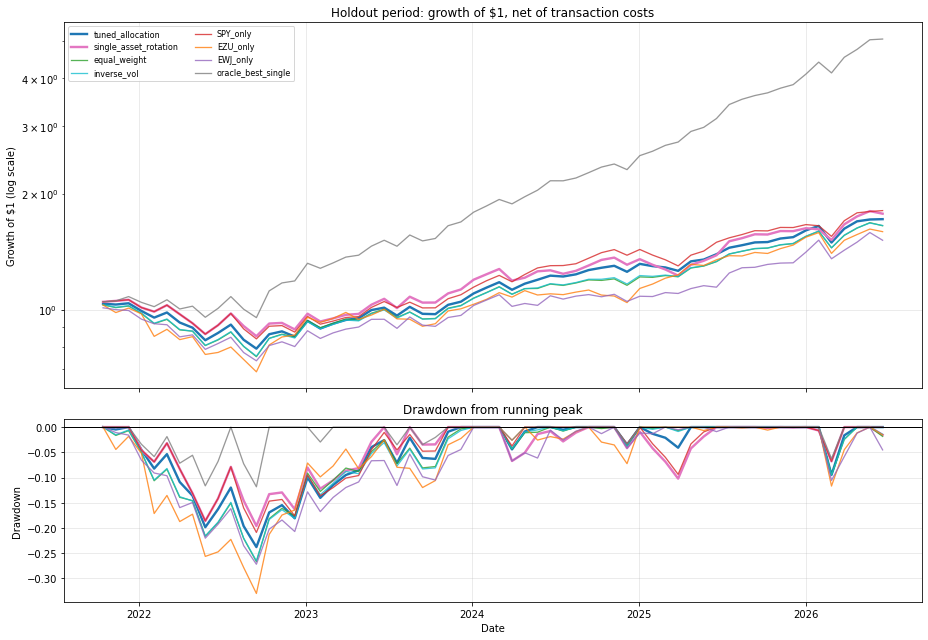

In [20]:
fig, (ax_growth, ax_dd) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                       gridspec_kw={"height_ratios": [2, 1]})

for name in STRATEGY_ORDER:
    growth = (1 + holdout_net[name]).cumprod()
    ax_growth.plot(growth.index.to_numpy(), growth.to_numpy(), label=name,
                   color=strategy_colors[name], linewidth=strategy_lw[name],
                   alpha=1.0 if strategy_lw[name] > 2 else 0.8)
    drawdown = growth / growth.cummax() - 1
    ax_dd.plot(drawdown.index.to_numpy(), drawdown.to_numpy(),
               color=strategy_colors[name], linewidth=strategy_lw[name],
               alpha=1.0 if strategy_lw[name] > 2 else 0.8)

ax_growth.set_yscale("log")
ax_growth.set_ylabel("Growth of $1 (log scale)")
ax_growth.set_title("Holdout period: growth of $1, net of transaction costs")
ax_growth.legend(fontsize=8, ncol=2)
ax_growth.grid(True, alpha=0.3)

ax_dd.axhline(0, linewidth=1, color="black")
ax_dd.set_ylabel("Drawdown")
ax_dd.set_xlabel("Date")
ax_dd.set_title("Drawdown from running peak")
ax_dd.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### What the allocation actually does

The stacked area chart is the visualization that has no analogue in the
previous notebook — it shows the portfolio the model is actually holding rather
than just the equity curve it produced. Below it, effective N (`1 / Σw²`)
summarizes concentration in one number: 1.0 means all-in on a single ETF, 3.0
means perfectly equal-weighted.

The shaded region is the tuning period. Weights there come from the same
out-of-sample predictions, but the *configuration* producing them was chosen
with knowledge of that period, so the left-hand side is not evidence.

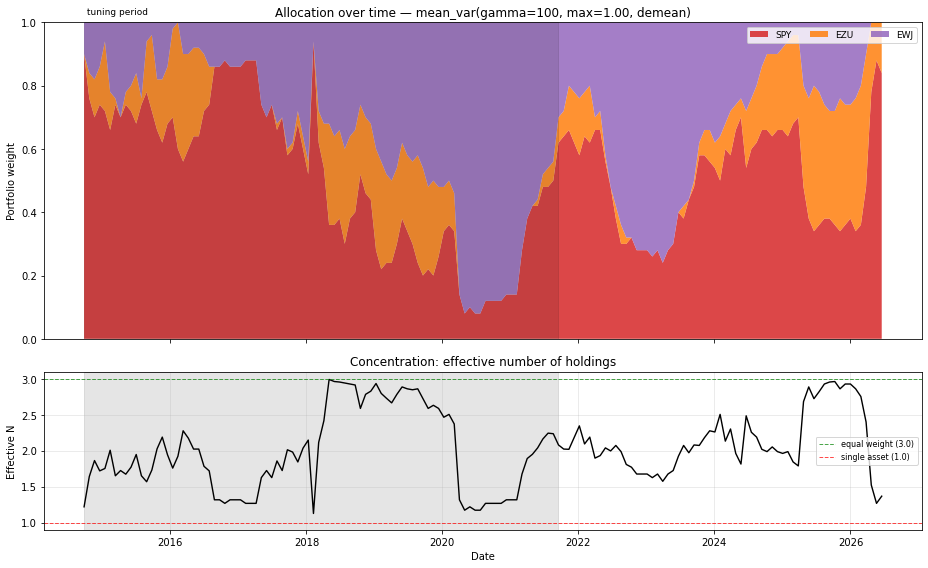

mean effective N over holdout: 2.14
mean weights over holdout:
SPY    0.502
EZU    0.163
EWJ    0.335


In [21]:
full_weights = build_weights(best_config, rebalance_dates)
effective_n = 1.0 / (full_weights ** 2).sum(axis=1)

fig, (ax_w, ax_n) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1]})

etf_colors = {"SPY": "#d62728", "EZU": "#ff7f0e", "EWJ": "#9467bd"}
ax_w.stackplot(full_weights.index.to_numpy(),
               *[full_weights[etf].to_numpy() for etf in ETFS],
               labels=ETFS, colors=[etf_colors[e] for e in ETFS], alpha=0.85)
ax_w.axvspan(tune_dates.min(), tune_dates.max(), color="black", alpha=0.10, zorder=5)
ax_w.text(tune_dates.min(), 1.02, " tuning period", fontsize=9, va="bottom")
ax_w.set_ylim(0, 1)
ax_w.set_ylabel("Portfolio weight")
ax_w.set_title(f"Allocation over time — {config_label(best_config)}")
ax_w.legend(loc="upper right", fontsize=9, ncol=3)

ax_n.plot(effective_n.index.to_numpy(), effective_n.to_numpy(), color="black", linewidth=1.4)
ax_n.axhline(len(ETFS), linestyle="--", linewidth=1, color="green", alpha=0.7,
             label="equal weight (3.0)")
ax_n.axhline(1.0, linestyle="--", linewidth=1, color="red", alpha=0.7,
             label="single asset (1.0)")
ax_n.axvspan(tune_dates.min(), tune_dates.max(), color="black", alpha=0.10)
ax_n.set_ylim(0.9, len(ETFS) + 0.1)
ax_n.set_ylabel("Effective N")
ax_n.set_xlabel("Date")
ax_n.set_title("Concentration: effective number of holdings")
ax_n.legend(fontsize=8)
ax_n.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"mean effective N over holdout: "
      f"{effective_n.loc[holdout_dates].mean():.2f}")
print("mean weights over holdout:")
print(full_weights.loc[holdout_dates].mean().round(3).to_string())

### Risk and return profile

Sharpe, volatility decomposition, and the shape of the period-return
distribution across every strategy. The downside-deviation bars matter for
reading the oracle in particular: its volatility is high, but nearly all of it
is upside dispersion.

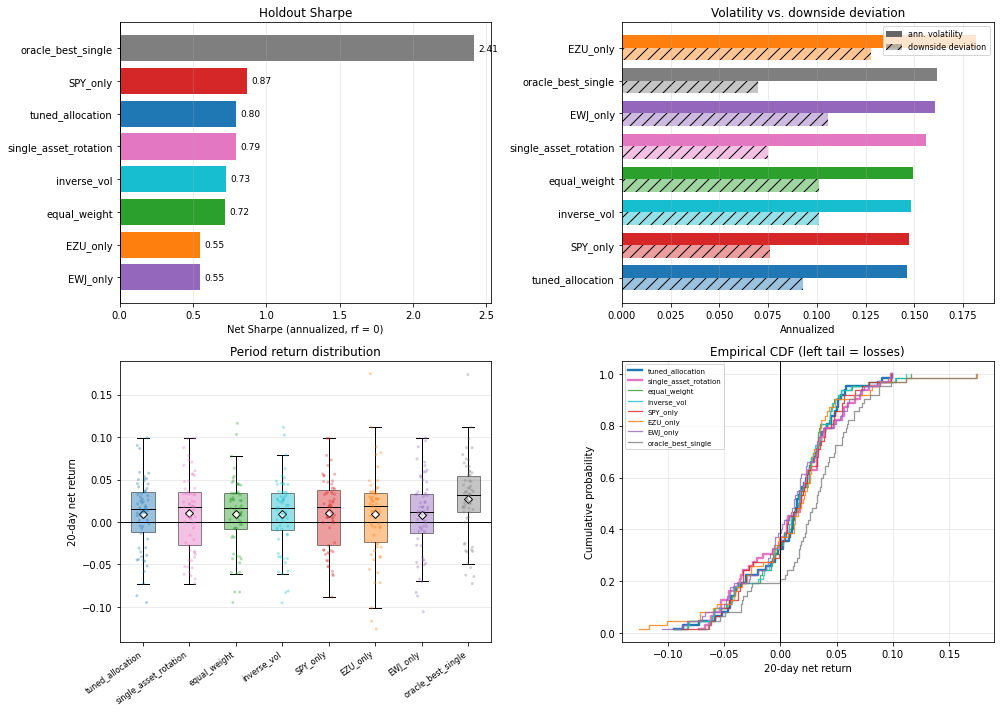

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
(ax_sharpe, ax_vol), (ax_box, ax_cdf) = axes

# --- Sharpe ---
sharpes = holdout_performance["sharpe"].sort_values()
bars = ax_sharpe.barh(sharpes.index.to_numpy(), sharpes.to_numpy(),
                      color=[strategy_colors[n] for n in sharpes.index])
for bar, v in zip(bars, sharpes.to_numpy()):
    ax_sharpe.text(v + 0.03 * np.sign(v) if np.isfinite(v) else 0,
                   bar.get_y() + bar.get_height() / 2, f"{v:.2f}",
                   va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax_sharpe.axvline(0, linewidth=1, color="black")
ax_sharpe.set_xlabel("Net Sharpe (annualized, rf = 0)")
ax_sharpe.set_title("Holdout Sharpe")
ax_sharpe.grid(True, axis="x", alpha=0.3)

# --- Volatility vs downside deviation ---
vol_table = holdout_performance[["ann_vol"]].copy()
vol_table["downside_dev"] = [
    holdout_net[n][holdout_net[n] < 0].std() * np.sqrt(PERIODS_PER_YEAR)
    for n in vol_table.index
]
vol_table = vol_table.sort_values("ann_vol")
y_pos, height = np.arange(len(vol_table)), 0.38
ax_vol.barh(y_pos + height / 2, vol_table["ann_vol"].to_numpy(), height=height,
            color=[strategy_colors[n] for n in vol_table.index])
ax_vol.barh(y_pos - height / 2, vol_table["downside_dev"].to_numpy(), height=height,
            color=[strategy_colors[n] for n in vol_table.index], alpha=0.45, hatch="//")
ax_vol.set_yticks(y_pos)
ax_vol.set_yticklabels(vol_table.index)
ax_vol.set_xlabel("Annualized")
ax_vol.set_title("Volatility vs. downside deviation")
ax_vol.legend(handles=[mpatches.Patch(facecolor="#666666", label="ann. volatility"),
                       mpatches.Patch(facecolor="#666666", alpha=0.45, hatch="//",
                                      label="downside deviation")], fontsize=8)
ax_vol.grid(True, axis="x", alpha=0.3)

# --- Return distribution ---
box = ax_box.boxplot([holdout_net[n].to_numpy() for n in STRATEGY_ORDER],
                     positions=np.arange(1, len(STRATEGY_ORDER) + 1),
                     patch_artist=True, showmeans=True,
                     medianprops={"color": "black"},
                     meanprops={"marker": "D", "markerfacecolor": "white",
                                "markeredgecolor": "black", "markersize": 5},
                     flierprops={"marker": "", "markersize": 0})
for patch, name in zip(box["boxes"], STRATEGY_ORDER):
    patch.set_facecolor(strategy_colors[name])
    patch.set_alpha(0.45)

rng = np.random.default_rng(0)
for i, name in enumerate(STRATEGY_ORDER, start=1):
    y = holdout_net[name].to_numpy()
    ax_box.scatter(i + rng.uniform(-0.13, 0.13, len(y)), y, s=9, alpha=0.35,
                   color=strategy_colors[name], edgecolors="none", zorder=3)
ax_box.axhline(0, linewidth=1, color="black")
ax_box.set_xticks(np.arange(1, len(STRATEGY_ORDER) + 1))
ax_box.set_xticklabels(STRATEGY_ORDER, rotation=35, ha="right", fontsize=8)
ax_box.set_ylabel(f"{REBALANCE_EVERY}-day net return")
ax_box.set_title("Period return distribution")
ax_box.grid(True, axis="y", alpha=0.3)

# --- Empirical CDF ---
for name in STRATEGY_ORDER:
    y = np.sort(holdout_net[name].to_numpy())
    ax_cdf.step(y, np.arange(1, len(y) + 1) / len(y), where="post", label=name,
                color=strategy_colors[name], linewidth=strategy_lw[name],
                alpha=1.0 if strategy_lw[name] > 2 else 0.8)
ax_cdf.axvline(0, linewidth=1, color="black")
ax_cdf.set_xlabel(f"{REBALANCE_EVERY}-day net return")
ax_cdf.set_ylabel("Cumulative probability")
ax_cdf.set_title("Empirical CDF (left tail = losses)")
ax_cdf.legend(fontsize=7)
ax_cdf.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### What turnover buys

Costs were the missing term in the previous notebook. This plots annualized
turnover against net annualized return: strategies to the left are cheap to
run, and the question is whether moving right buys anything.

Don't assume the gradual strategy sits on the left. All-in rotation trades two
full legs when it switches but nothing when it holds, whereas a softmax or
mean-variance allocation adjusts slightly every period — so the ranking here
depends on how often the argmax actually flips, and is worth reading rather
than predicting.

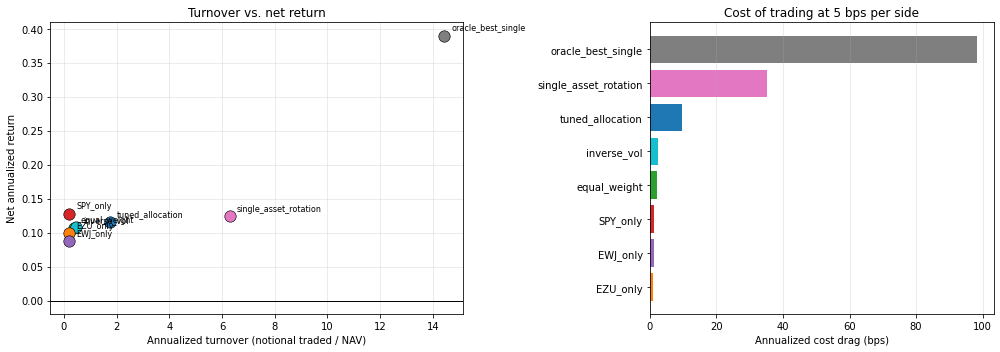

In [23]:
fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=(14, 5),
                                         gridspec_kw={"width_ratios": [1.2, 1]})

for name in STRATEGY_ORDER:
    ax_scatter.scatter(holdout_performance.loc[name, "ann_turnover"],
                       holdout_performance.loc[name, "ann_return"],
                       s=130, color=strategy_colors[name], label=name,
                       edgecolors="black", linewidths=0.6, zorder=3)
    ax_scatter.annotate(name,
                        (holdout_performance.loc[name, "ann_turnover"],
                         holdout_performance.loc[name, "ann_return"]),
                        textcoords="offset points", xytext=(7, 5), fontsize=8)

ax_scatter.axhline(0, linewidth=1, color="black")
ax_scatter.set_xlabel("Annualized turnover (notional traded / NAV)")
ax_scatter.set_ylabel("Net annualized return")
ax_scatter.set_title("Turnover vs. net return")
ax_scatter.grid(True, alpha=0.3)

gross_ann = pd.Series({
    n: (1 + holdout_bt[n]["gross"]).prod() ** (PERIODS_PER_YEAR / len(holdout_dates)) - 1
    for n in STRATEGY_ORDER
})
drag = (gross_ann - holdout_performance["ann_return"]).sort_values()

ax_bar.barh(drag.index.to_numpy(), (drag * 1e4).to_numpy(),
            color=[strategy_colors[n] for n in drag.index])
ax_bar.set_xlabel("Annualized cost drag (bps)")
ax_bar.set_title(f"Cost of trading at {COST_BPS:.0f} bps per side")
ax_bar.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()